# Advanced Histological Structures Gallery

PointillSim provides a rich library of **histological elements** that simulate real tissue structures. This notebook showcases all available structure types with beautiful visualizations.

## Structure Types

1. **VacuolatedStructure** - Glands and acini with central lumens
2. **LinearLumenStructure** - Vessels, ducts, and tubes
3. **LayeredElement** - Stratified layers (skin, cortex)
4. **BranchingStructure** - Tree-like structures (vasculature, neurons)
5. **FibrillarStructure** - Collagen bundles, muscle fibers
6. **ClusterElement** - Cell aggregates (lymphoid follicles)
7. **GlandularUnit** - Complete glandular structures
8. **InterfaceElement** - Tissue boundaries and transitions
9. **StromalElement** - Background connective tissue

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors

np.random.seed(42)

from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOVDistribution,
    FrameWideElement,
    RandomCellTypeRule,
    MixOfNCellTypesRule,
    SingleTypeRule,
    DistanceBasedRule,
    ProbabilityNodeFieldRule,
)

from pointillsim.rules.composite import LayerRule, GradientRule, CompositeRule

# Import all structure elements
from pointillsim.elements import (
    HistologicalElement,
    VacuolatedStructure,
    LinearLumenStructure,
    LayeredElement,
    BranchingStructure,
    FibrillarStructure,
    ClusterElement,
    GlandularUnit,
    InterfaceElement,
    StromalElement,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# Use a beautiful color palette
colors = plt.cm.Set2(np.linspace(0, 1, 8))
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Setup shared components
n_cell_types = 6
frame_size = 500

tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=40,
    n_cell_types=n_cell_types,
    expected_level=12.0,
    concentration=0.85,
)
tissue._cell_type_names = ['Epithelial', 'Stromal', 'Endothelial', 'Immune', 'Muscle', 'Nerve']

cell_props = CellTypesProperties(
    n_cell_types=n_cell_types,
    sizes=[12, 15, 10, 8, 18, 14],
    anisotropy=[0.85, 0.7, 0.9, 0.95, 0.6, 0.75],
)

# Beautiful visualization helper
def visualize_element(element, title, show_polygon=True, ax=None):
    """Create a beautiful visualization of a histological element."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Apply cell properties
    cell_props.apply(element)
    
    # Draw cells as ellipses
    ellipses = []
    cell_colors = []
    
    for i in range(len(element.cell_centroids)):
        ellipse = Ellipse(
            xy=(element.cell_centroids[i, 0], element.cell_centroids[i, 1]),
            width=2 * element.cell_major_axis[i],
            height=2 * element.cell_minor_axis[i],
            angle=np.degrees(element.cell_rotation[i]),
        )
        ellipses.append(ellipse)
        cell_colors.append(element.cell_colors[i])
    
    collection = PatchCollection(ellipses, alpha=0.7)
    collection.set_facecolors(cell_colors)
    collection.set_edgecolors('black')
    collection.set_linewidths(0.3)
    ax.add_collection(collection)
    
    # Draw polygon boundary if available
    if show_polygon and hasattr(element, 'polygon') and element.polygon is not None:
        try:
            coords = np.array(element.polygon.exterior.coords)
            ax.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=2, alpha=0.5)
        except:
            pass
    
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\n({len(element.cell_centroids)} cells)', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    
    return ax

print("Visualization helper ready")

Visualization helper ready


---
## 1. VacuolatedStructure

Circular structures with **central lumens** (holes). Perfect for:
- Glands and acini
- Crypts
- Follicles

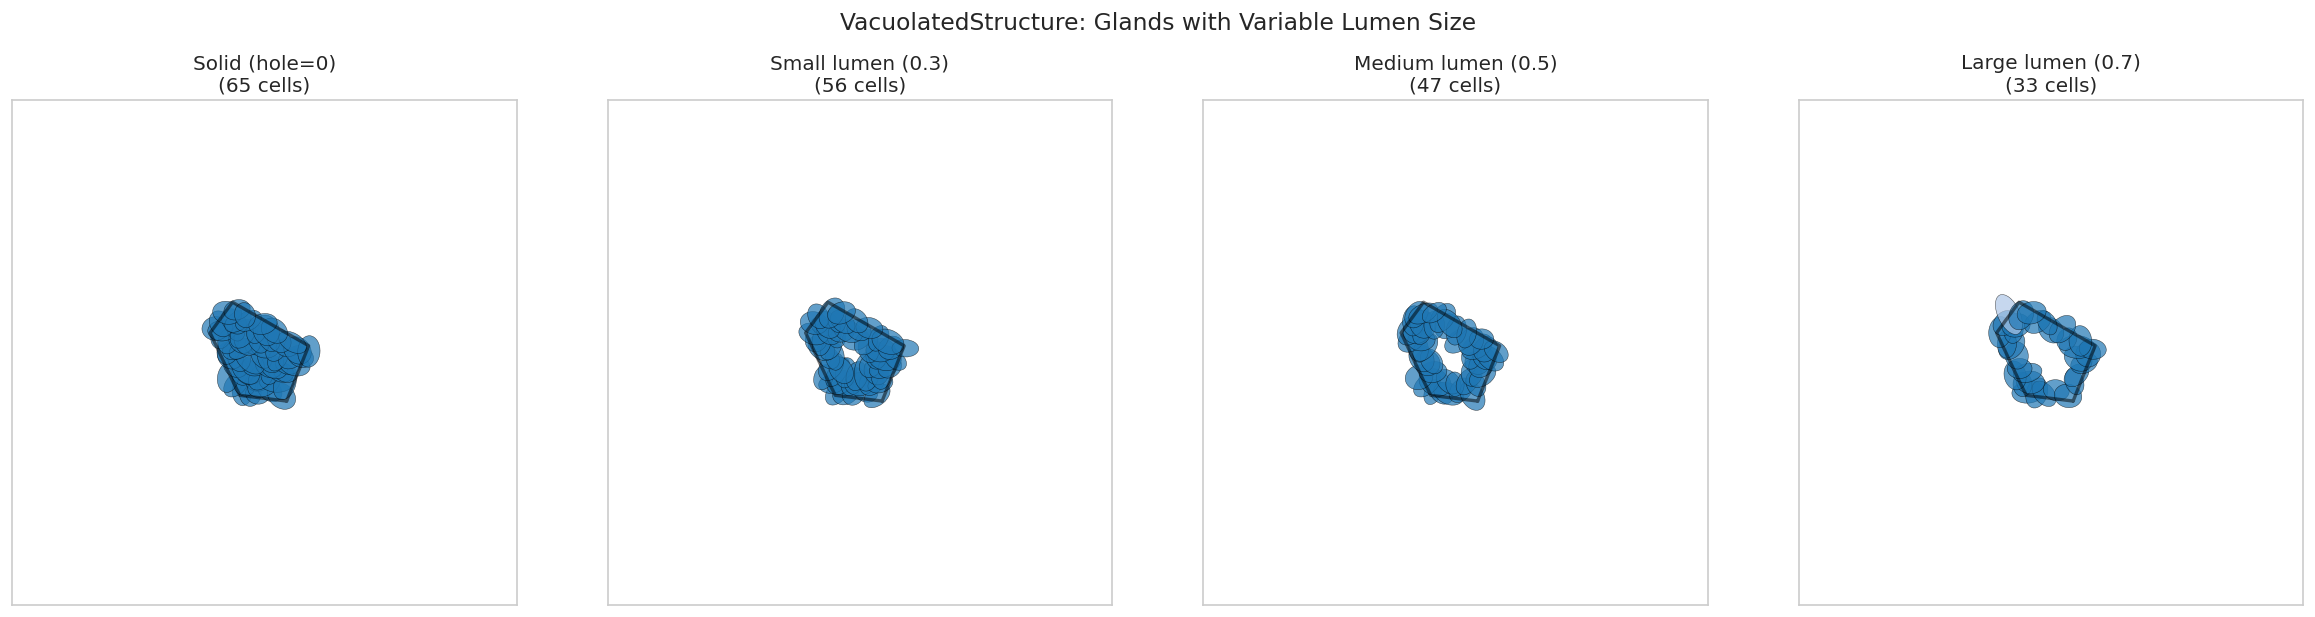

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Vary hole size
hole_sizes = [0.0, 0.3, 0.5, 0.7]
titles = ['Solid (hole=0)', 'Small lumen (0.3)', 'Medium lumen (0.5)', 'Large lumen (0.7)']

for ax, hole, title in zip(axes, hole_sizes, titles):
    np.random.seed(42)
    
    element = VacuolatedStructure(
        frame_size=frame_size,
        scale=120,
        hole_scale_factor=hole,
        fixed_center=np.array([[250, 250]]),
        tipical_cell_spacing=10,
        rules=LayerRule(
            n_cell_types=n_cell_types,
            layer_types=[0, 1],  # Epithelial inner, Stromal outer
            layer_boundaries=[0.6],
            transition_width=8,
        ),
    ).generate()
    
    visualize_element(element, title, ax=ax)

plt.suptitle('VacuolatedStructure: Glands with Variable Lumen Size', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. LinearLumenStructure

**Tubular structures** like vessels and ducts. Features:
- Elongated shape with central lumen
- Variable wall thickness
- Can be curved or branched

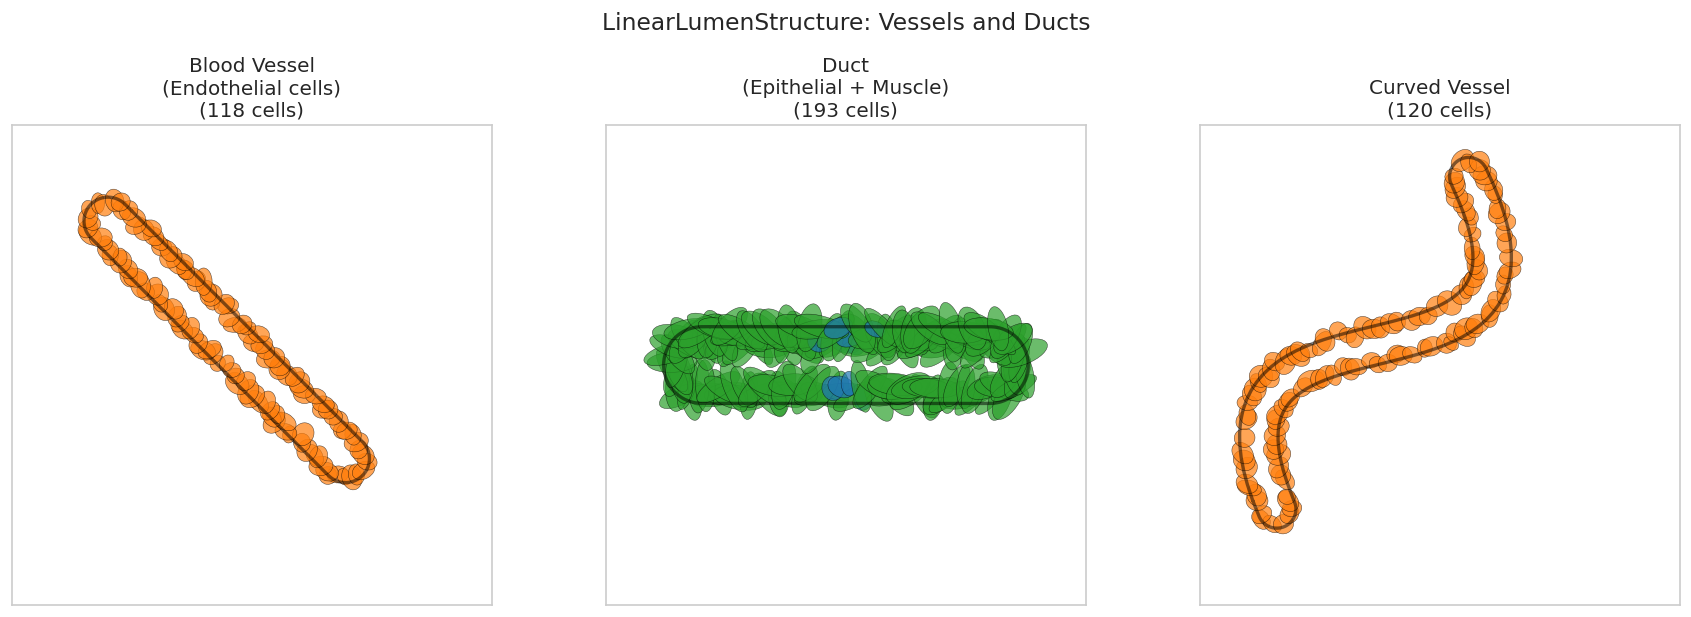

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Different vessel configurations
np.random.seed(42)

# Blood vessel (thin wall)
vessel = LinearLumenStructure(
    frame_size=frame_size,
    length=350,
    outer_radius=25,
    wall_thickness=8,
    curvature=0,  # Straight
    fixed_start=np.array([100, 400]),
    fixed_angle=-np.pi/4,  # Diagonal direction
    tipical_cell_spacing=8,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=2),  # Endothelial
).generate()

visualize_element(vessel, 'Blood Vessel\n(Endothelial cells)', ax=axes[0])

# Duct (thick wall)
np.random.seed(43)
duct = LinearLumenStructure(
    frame_size=frame_size,
    length=300,
    outer_radius=40,
    wall_thickness=20,
    curvature=0,
    fixed_start=np.array([100, 250]),
    fixed_angle=0,  # Horizontal
    tipical_cell_spacing=10,
    rules=LayerRule(
        n_cell_types=n_cell_types,
        layer_types=[0, 4],  # Epithelial inner, Muscle outer
        layer_boundaries=[0.6],
        transition_width=10,
    ),
).generate()

visualize_element(duct, 'Duct\n(Epithelial + Muscle)', ax=axes[1])

# Curved vessel
np.random.seed(44)
curved = LinearLumenStructure(
    frame_size=frame_size,
    length=400,
    outer_radius=20,
    wall_thickness=6,
    curvature=0.2,  # Curved path
    n_control_points=4,
    fixed_start=np.array([80, 100]),
    fixed_angle=np.pi/3,
    tipical_cell_spacing=8,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=2),
).generate()

visualize_element(curved, 'Curved Vessel', ax=axes[2])

plt.suptitle('LinearLumenStructure: Vessels and Ducts', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. LayeredElement

**Stratified layers** like epidermis or cortical layers.

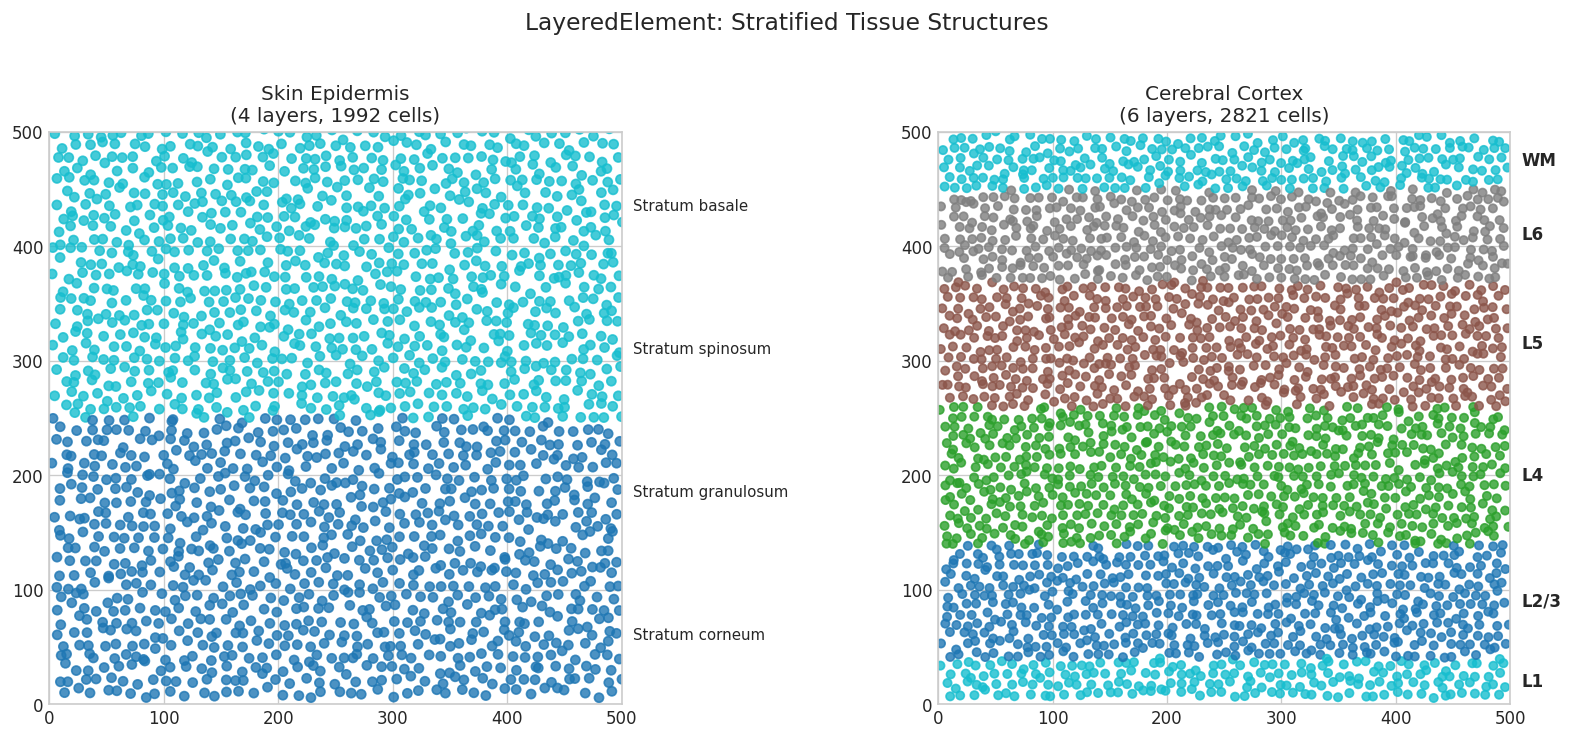

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Skin-like epidermis (4 layers)
np.random.seed(42)

# Create rules for each layer
from pointillsim.rules import DummyRule
layer_rules_skin = [
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[0], proportions=[1.0]),  # Stratum corneum
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[0], proportions=[1.0]),  # Granulosum
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[1], proportions=[1.0]),  # Spinosum
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[1], proportions=[1.0]),  # Basale
]

epidermis = LayeredElement(
    frame_size=frame_size,
    layer_boundaries=[125, 250, 375],  # 3 boundaries = 4 layers
    layer_rules=layer_rules_skin,
    orientation='horizontal',
    tipical_cell_spacing=12,
).generate()

cell_props.apply(epidermis)

ax = axes[0]
scatter = ax.scatter(
    epidermis.cell_centroids[:, 0],
    epidermis.cell_centroids[:, 1],
    c=epidermis.class_instance,
    cmap='tab10',
    s=30, alpha=0.8
)
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title(f'Skin Epidermis\n(4 layers, {len(epidermis.cell_centroids)} cells)')

# Add layer labels
layer_names = ['Stratum corneum', 'Stratum granulosum', 'Stratum spinosum', 'Stratum basale']
layer_y = [60, 185, 310, 435]
for name, y in zip(layer_names, layer_y):
    ax.text(510, y, name, fontsize=9, va='center')

# Cortex-like layers (6 layers)
np.random.seed(43)

layer_rules_cortex = [
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[5], proportions=[1.0]),  # L1
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[1], proportions=[1.0]),  # L2/3
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[2], proportions=[1.0]),  # L4
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[3], proportions=[1.0]),  # L5
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[4], proportions=[1.0]),  # L6
    MixOfNCellTypesRule(n_cell_types=n_cell_types, list_N=[5], proportions=[1.0]),  # WM
]

cortex = LayeredElement(
    frame_size=frame_size,
    layer_boundaries=[40, 140, 260, 370, 450],  # 5 boundaries = 6 layers
    layer_rules=layer_rules_cortex,
    orientation='horizontal',
    tipical_cell_spacing=10,
).generate()

cell_props.apply(cortex)

ax = axes[1]
scatter = ax.scatter(
    cortex.cell_centroids[:, 0],
    cortex.cell_centroids[:, 1],
    c=cortex.class_instance,
    cmap='tab10',
    s=25, alpha=0.8
)
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title(f'Cerebral Cortex\n(6 layers, {len(cortex.cell_centroids)} cells)')

# Add layer labels
layer_names = ['L1', 'L2/3', 'L4', 'L5', 'L6', 'WM']
layer_y = [20, 90, 200, 315, 410, 475]
for name, y in zip(layer_names, layer_y):
    ax.text(510, y, name, fontsize=10, va='center', fontweight='bold')

plt.suptitle('LayeredElement: Stratified Tissue Structures', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. BranchingStructure

**Tree-like branching patterns** for vasculature, nerves, and ductal systems.

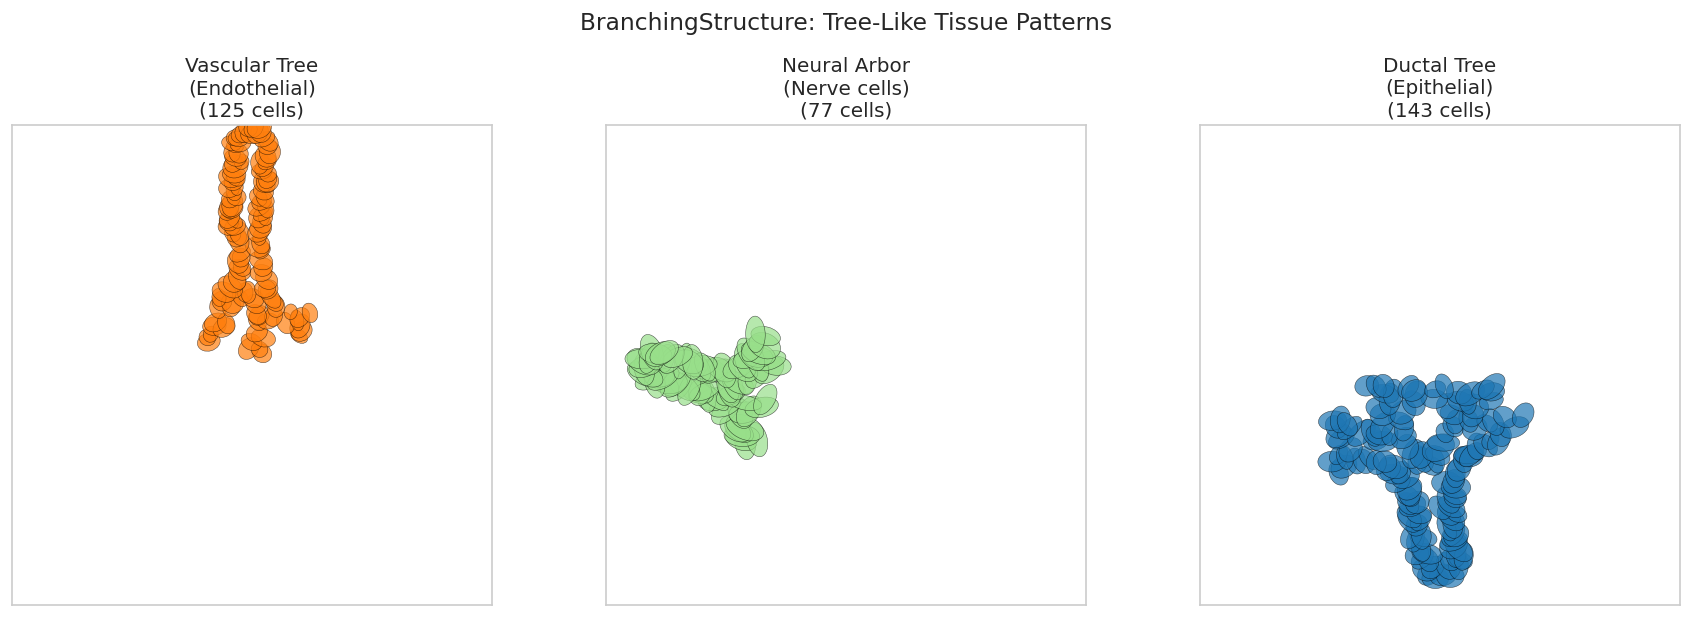

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Vascular tree
np.random.seed(42)
vascular = BranchingStructure(
    frame_size=frame_size,
    root_position=np.array([250, 480]),
    root_angle=-np.pi/2,  # Pointing down
    root_radius=20,
    wall_thickness=0.4,  # Fraction of radius
    branch_length=80,
    branch_length_decay=0.7,
    radius_decay=0.7,
    branching_angle=(0.5, 0.7),  # Radians
    branching_probability=0.8,
    max_depth=4,
    min_radius=3,
    tipical_cell_spacing=6,
    curvature=0.1,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=2),  # Endothelial
).generate()

visualize_element(vascular, 'Vascular Tree\n(Endothelial)', show_polygon=False, ax=axes[0])

# Neural arbor
np.random.seed(43)
neural = BranchingStructure(
    frame_size=frame_size,
    root_position=np.array([50, 250]),
    root_angle=0,  # Pointing right
    root_radius=15,
    wall_thickness=0.3,
    branch_length=60,
    branch_length_decay=0.65,
    radius_decay=0.6,
    branching_angle=(0.4, 0.6),
    branching_probability=0.9,
    max_depth=5,
    min_radius=2,
    tipical_cell_spacing=5,
    curvature=0.12,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=5),  # Nerve
).generate()

visualize_element(neural, 'Neural Arbor\n(Nerve cells)', show_polygon=False, ax=axes[1])

# Ductal tree
np.random.seed(44)
ductal = BranchingStructure(
    frame_size=frame_size,
    root_position=np.array([250, 50]),
    root_angle=np.pi/2,  # Pointing up
    root_radius=25,
    wall_thickness=0.5,
    branch_length=70,
    branch_length_decay=0.75,
    radius_decay=0.75,
    branching_angle=(0.6, 0.8),
    branching_probability=0.7,
    max_depth=3,
    min_radius=5,
    tipical_cell_spacing=8,
    curvature=0.08,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=0),  # Epithelial
).generate()

visualize_element(ductal, 'Ductal Tree\n(Epithelial)', show_polygon=False, ax=axes[2])

plt.suptitle('BranchingStructure: Tree-Like Tissue Patterns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. FibrillarStructure

**Parallel fiber bundles** like collagen, muscle fibers, or nerve tracts.

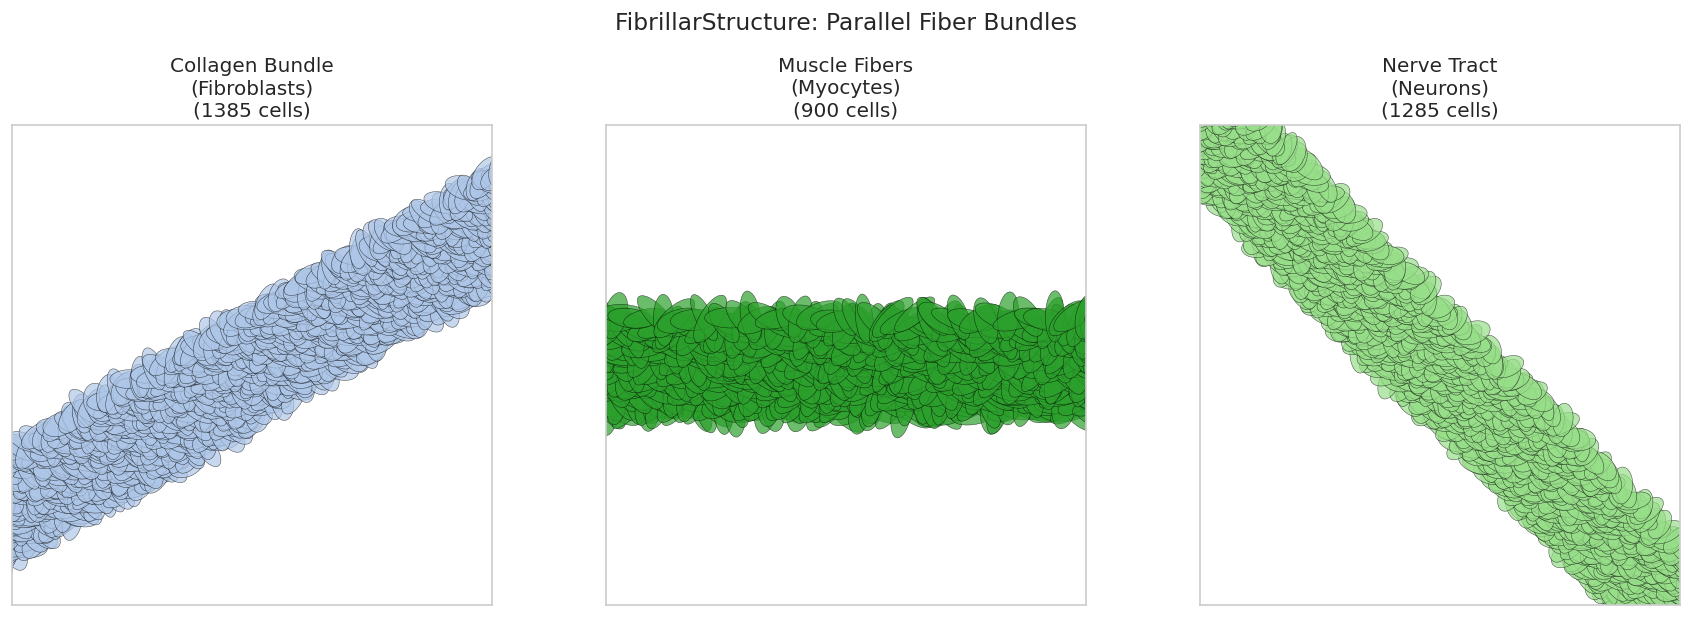

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Collagen bundle
np.random.seed(42)
collagen = FibrillarStructure(
    frame_size=frame_size,
    n_fibers=12,
    fiber_width=15,
    fiber_spacing=8,
    orientation=np.radians(30),  # 30 degrees in radians
    waviness=0.1,
    fixed_center=np.array([250, 250]),
    tipical_cell_spacing=8,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=1),  # Stromal
).generate()

visualize_element(collagen, 'Collagen Bundle\n(Fibroblasts)', show_polygon=False, ax=axes[0])

# Muscle fibers
np.random.seed(43)
muscle = FibrillarStructure(
    frame_size=frame_size,
    n_fibers=8,
    fiber_width=25,
    fiber_spacing=12,
    orientation=0,  # Horizontal
    waviness=0.05,
    fixed_center=np.array([250, 250]),
    tipical_cell_spacing=10,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=4),  # Muscle
).generate()

visualize_element(muscle, 'Muscle Fibers\n(Myocytes)', show_polygon=False, ax=axes[1])

# Nerve tract
np.random.seed(44)
nerve = FibrillarStructure(
    frame_size=frame_size,
    n_fibers=6,
    fiber_width=20,
    fiber_spacing=15,
    orientation=np.radians(-45),  # -45 degrees
    waviness=0.15,
    fixed_center=np.array([250, 250]),
    tipical_cell_spacing=8,
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=5),  # Nerve
).generate()

visualize_element(nerve, 'Nerve Tract\n(Neurons)', show_polygon=False, ax=axes[2])

plt.suptitle('FibrillarStructure: Parallel Fiber Bundles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. ClusterElement

**Aggregates of cells** with shared properties, like lymphoid follicles or tumor nests.

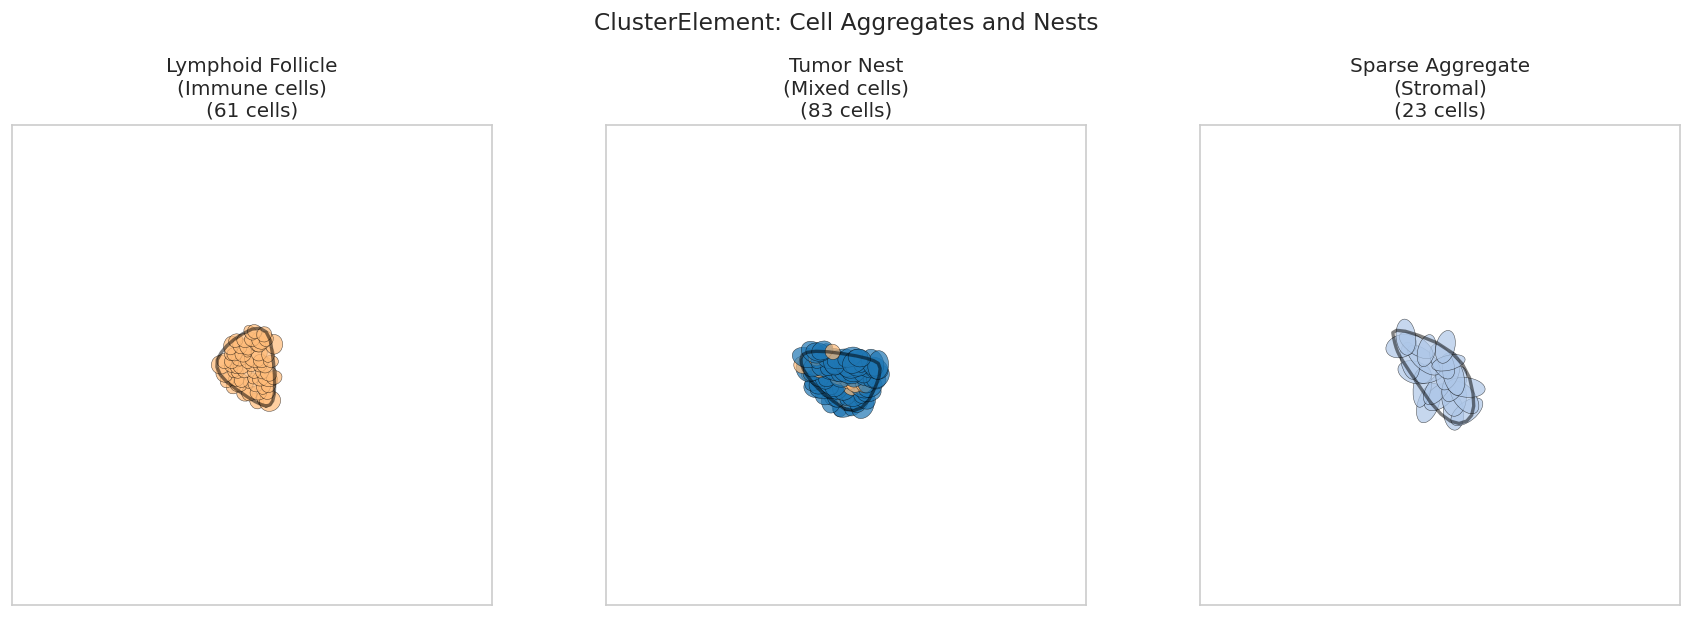

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Lymphoid follicle
np.random.seed(42)
follicle = ClusterElement(
    frame_size=frame_size,
    fixed_center=np.array([250, 250]),
    radius=100,
    density_profile='gaussian',
    tipical_cell_spacing=8,
    rules=DistanceBasedRule(
        n_cell_types=n_cell_types,
        inner_type=3,  # Immune center (germinal center)
        outer_type=3,  # Immune periphery (mantle zone)
        transition_width=30,
    ),
).generate()

visualize_element(follicle, 'Lymphoid Follicle\n(Immune cells)', ax=axes[0])

# Dense tumor nest
np.random.seed(43)
tumor = ClusterElement(
    frame_size=frame_size,
    fixed_center=np.array([250, 250]),
    radius=120,
    density_profile='uniform',
    tipical_cell_spacing=7,  # Dense packing
    rules=MixOfNCellTypesRule(
        n_cell_types=n_cell_types,
        list_N=[0, 3],  # Mix of epithelial and immune (tumor infiltrating)
        proportions=[0.85, 0.15],
    ),
).generate()

visualize_element(tumor, 'Tumor Nest\n(Mixed cells)', ax=axes[1])

# Sparse aggregate
np.random.seed(44)
sparse = ClusterElement(
    frame_size=frame_size,
    fixed_center=np.array([250, 250]),
    radius=140,
    density_profile='exponential',
    tipical_cell_spacing=15,  # Sparse
    rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=1),
).generate()

visualize_element(sparse, 'Sparse Aggregate\n(Stromal)', ax=axes[2])

plt.suptitle('ClusterElement: Cell Aggregates and Nests', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. GlandularUnit

**Complete glandular structures** with ducts, acini, and surrounding stroma.

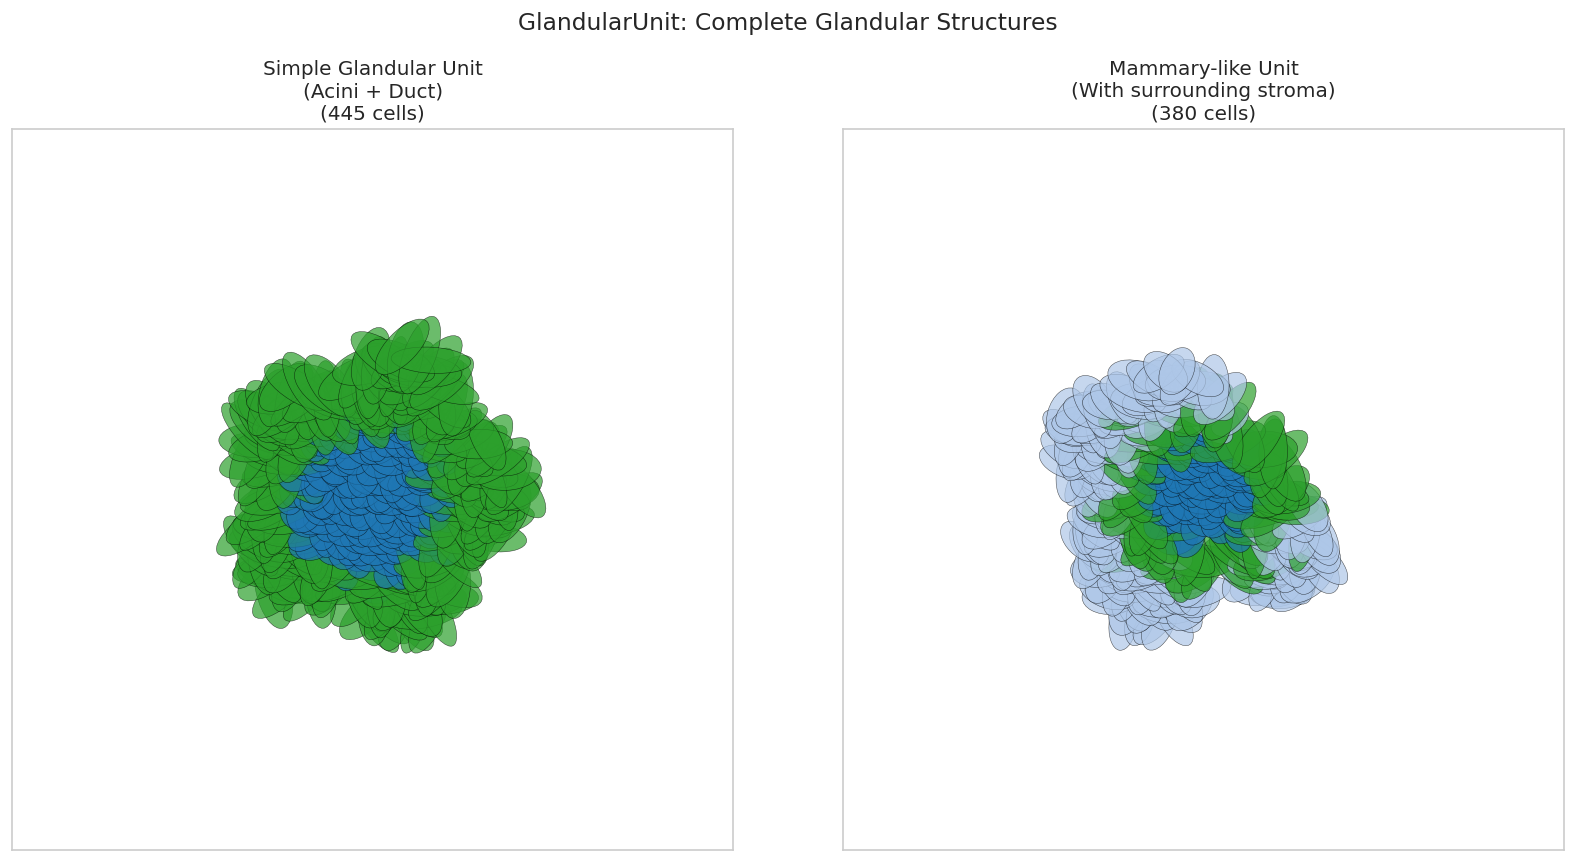

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Simple glandular unit
np.random.seed(42)
simple_gland = GlandularUnit(
    frame_size=frame_size,
    fixed_center=np.array([250, 250]),
    n_acini=5,
    acinus_radius=40,
    central_duct=True,
    duct_radius=20,
    arrangement='circular',
    tipical_cell_spacing=8,
    rules=LayerRule(
        n_cell_types=n_cell_types,
        layer_types=[0, 4],  # Epithelial inner, Myoepithelial outer
        layer_boundaries=[0.7],
        transition_width=5,
    ),
).generate()

visualize_element(simple_gland, 'Simple Glandular Unit\n(Acini + Duct)', show_polygon=False, ax=axes[0])

# Complex mammary-like unit
np.random.seed(43)
mammary = GlandularUnit(
    frame_size=frame_size,
    fixed_center=np.array([250, 250]),
    n_acini=8,
    acinus_radius=35,
    central_duct=True,
    duct_radius=25,
    arrangement='clustered',
    tipical_cell_spacing=8,
    rules=LayerRule(
        n_cell_types=n_cell_types,
        layer_types=[0, 4, 1],  # Epithelial, Myoepithelial, Stroma
        layer_boundaries=[0.6, 0.85],
        transition_width=8,
    ),
).generate()

visualize_element(mammary, 'Mammary-like Unit\n(With surrounding stroma)', show_polygon=False, ax=axes[1])

plt.suptitle('GlandularUnit: Complete Glandular Structures', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. InterfaceElement

**Tissue boundaries and transition zones** between different tissue types.

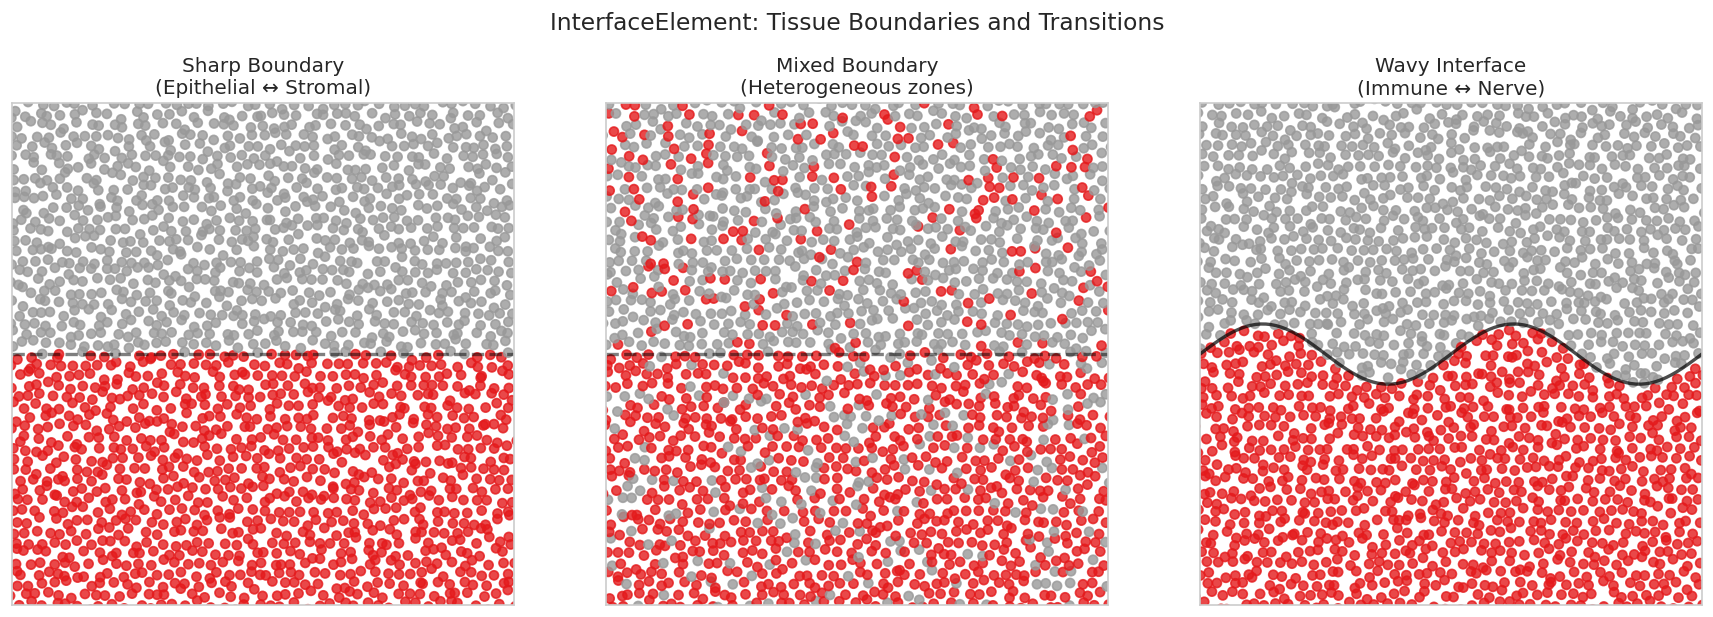

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sharp boundary
np.random.seed(42)
sharp = InterfaceElement(
    frame_size=frame_size,
    interface_position=0.5,  # Middle of FOV
    interface_width=10,  # Sharp transition
    orientation='horizontal',
    waviness=0,  # Straight line
    tipical_cell_spacing=12,
    rules_side_a=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=0),  # Epithelial below
    rules_side_b=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=1),  # Stromal above
).generate()

cell_props.apply(sharp)
ax = axes[0]
scatter = ax.scatter(
    sharp.cell_centroids[:, 0],
    sharp.cell_centroids[:, 1],
    c=sharp.class_instance,
    cmap='Set1',
    s=30, alpha=0.8
)
ax.axhline(250, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title('Sharp Boundary\n(Epithelial ↔ Stromal)')
ax.set_xticks([])
ax.set_yticks([])

# Gradual transition - use mixed cell types near boundary
np.random.seed(43)
gradual = InterfaceElement(
    frame_size=frame_size,
    interface_position=0.5,
    interface_width=10,  # Sharp classification
    orientation='horizontal',
    waviness=0,
    tipical_cell_spacing=12,
    # Use MixOfNCellTypesRule to create heterogeneity on each side
    rules_side_a=MixOfNCellTypesRule(
        n_cell_types=n_cell_types,
        list_N=[0, 1],  # Mix of Epithelial and Stromal
        proportions=[0.8, 0.2]  # Mostly epithelial, some stromal infiltration
    ),
    rules_side_b=MixOfNCellTypesRule(
        n_cell_types=n_cell_types,
        list_N=[1, 0],  # Mix of Stromal and Epithelial
        proportions=[0.8, 0.2]  # Mostly stromal, some epithelial infiltration
    ),
).generate()

cell_props.apply(gradual)
ax = axes[1]
scatter = ax.scatter(
    gradual.cell_centroids[:, 0],
    gradual.cell_centroids[:, 1],
    c=gradual.class_instance,
    cmap='Set1',
    s=30, alpha=0.8
)
ax.axhline(250, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title('Mixed Boundary\n(Heterogeneous zones)')
ax.set_xticks([])
ax.set_yticks([])

# Wavy interface - FIXED with gentler parameters
np.random.seed(44)
wavy = InterfaceElement(
    frame_size=frame_size,
    interface_position=0.5,
    interface_width=30,
    orientation='horizontal',
    waviness=0.06,  # Reduced from 0.15 for clearer pattern
    n_waves=2,  # Reduced from 4 for clearer pattern
    tipical_cell_spacing=12,
    rules_side_a=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=3),  # Immune below
    rules_side_b=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=5),  # Nerve above
).generate()

cell_props.apply(wavy)
ax = axes[2]
scatter = ax.scatter(
    wavy.cell_centroids[:, 0],
    wavy.cell_centroids[:, 1],
    c=wavy.class_instance,
    cmap='Set1',
    s=30, alpha=0.8
)

# Draw the actual wavy interface line
if hasattr(wavy, 'interface_line') and wavy.interface_line is not None:
    ax.plot(wavy.interface_line[:, 0], wavy.interface_line[:, 1], 'k-', linewidth=2, alpha=0.7, label='Interface')

ax.set_xlim(0, frame_size)
ax.set_ylim(0, frame_size)
ax.set_aspect('equal')
ax.set_title('Wavy Interface\n(Immune ↔ Nerve)')
ax.set_xticks([])
ax.set_yticks([])

plt.suptitle('InterfaceElement: Tissue Boundaries and Transitions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. StromalElement

**Background connective tissue** with variable density and composition.

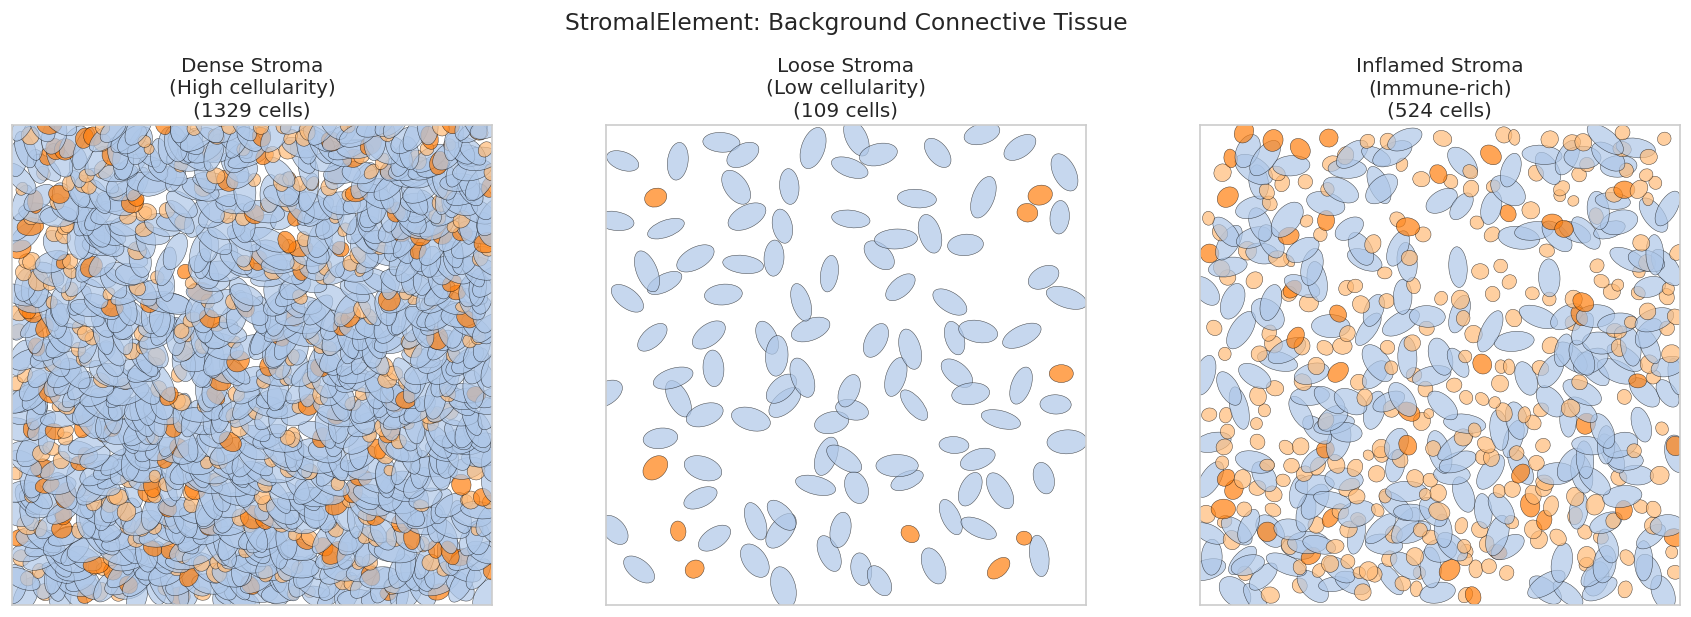

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dense stroma
np.random.seed(42)
dense = StromalElement(
    frame_size=frame_size,
    cell_density=0.8,  # High cellularity
    heterogeneity=0.3,
    tipical_cell_spacing=12,
    rules=MixOfNCellTypesRule(
        n_cell_types=n_cell_types,
        list_N=[1, 3, 2],  # Stromal, Immune, Endothelial
        proportions=[0.7, 0.2, 0.1],
    ),
).generate()

visualize_element(dense, 'Dense Stroma\n(High cellularity)', show_polygon=False, ax=axes[0])

# Loose stroma
np.random.seed(43)
loose = StromalElement(
    frame_size=frame_size,
    cell_density=0.3,  # Low cellularity
    heterogeneity=0.2,
    tipical_cell_spacing=25,
    rules=MixOfNCellTypesRule(
        n_cell_types=n_cell_types,
        list_N=[1, 2],  # Mostly fibroblasts, some vessels
        proportions=[0.9, 0.1],
    ),
).generate()

visualize_element(loose, 'Loose Stroma\n(Low cellularity)', show_polygon=False, ax=axes[1])

# Inflamed stroma (immune-rich)
np.random.seed(44)
inflamed = StromalElement(
    frame_size=frame_size,
    cell_density=0.6,  # Medium cellularity
    heterogeneity=0.5,  # High heterogeneity
    tipical_cell_spacing=15,
    rules=MixOfNCellTypesRule(
        n_cell_types=n_cell_types,
        list_N=[1, 3, 2],  # Fibroblasts, Immune, Vessels
        proportions=[0.4, 0.5, 0.1],  # High immune infiltration
    ),
).generate()

visualize_element(inflamed, 'Inflamed Stroma\n(Immune-rich)', show_polygon=False, ax=axes[2])

plt.suptitle('StromalElement: Background Connective Tissue', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Combining Structures: Complex Tissue Simulation

Let's create a beautiful, complex tissue by combining multiple structure types.

In [12]:
# Create a complex tissue scene
np.random.seed(42)
frame_size_large = 800

# FOV distribution with multiple structure types
fov_dist = FOVDistribution(
    frame_size=frame_size_large,
    # Stromal background
    background_element=lambda: FrameWideElement(
        frame_size=frame_size_large,
        tipical_cell_spacing=25,
        rules=MixOfNCellTypesRule(
            n_cell_types=n_cell_types,
            list_N=[1, 2, 3],
            proportions=[0.7, 0.15, 0.15]
        )
    ),
    # Foreground elements
    other_elements=[
        # Glandular structures
        lambda: VacuolatedStructure(
            frame_size=frame_size_large,
            scale=70,
            hole_scale_factor=0.5,
            tipical_cell_spacing=10,
            rules=LayerRule(
                n_cell_types=n_cell_types,
                layer_types=[0, 4],
                layer_boundaries=[0.6],
                transition_width=8,
            ),
        ),
        # Blood vessels
        lambda: LinearLumenStructure(
            frame_size=frame_size_large,
            length=np.random.uniform(200, 400),
            outer_radius=np.random.uniform(15, 30),
            wall_thickness=np.random.uniform(5, 10),
            curvature=np.random.uniform(0.05, 0.15),
            n_control_points=4,
            tipical_cell_spacing=8,
            rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=2),
        ),
        # Immune aggregates
        lambda: ClusterElement(
            frame_size=frame_size_large,
            fixed_center=np.array([
                np.random.uniform(100, 700),
                np.random.uniform(100, 700)
            ]),
            radius=50,
            density_profile='gaussian',
            tipical_cell_spacing=8,
            rules=SingleTypeRule(n_cell_types=n_cell_types, cell_type_ix=3),
        ),
    ],
    elements_frequency=[0.4, 0.35, 0.25],
    attempts_at_elements=[5, 3, 3],
)

# Generate FOV
fov = fov_dist.generate_fov()
cell_props.apply(fov)

# Generate observations
hybiss = HybISS_Setup(tissue)
hybiss.observe_dots(fov)
dots_df = hybiss.make_pandas_df()

print(f"Complex tissue: {fov.n_cells} cells, {len(dots_df):,} transcripts")

Complex tissue: 1309 cells, 19,218 transcripts


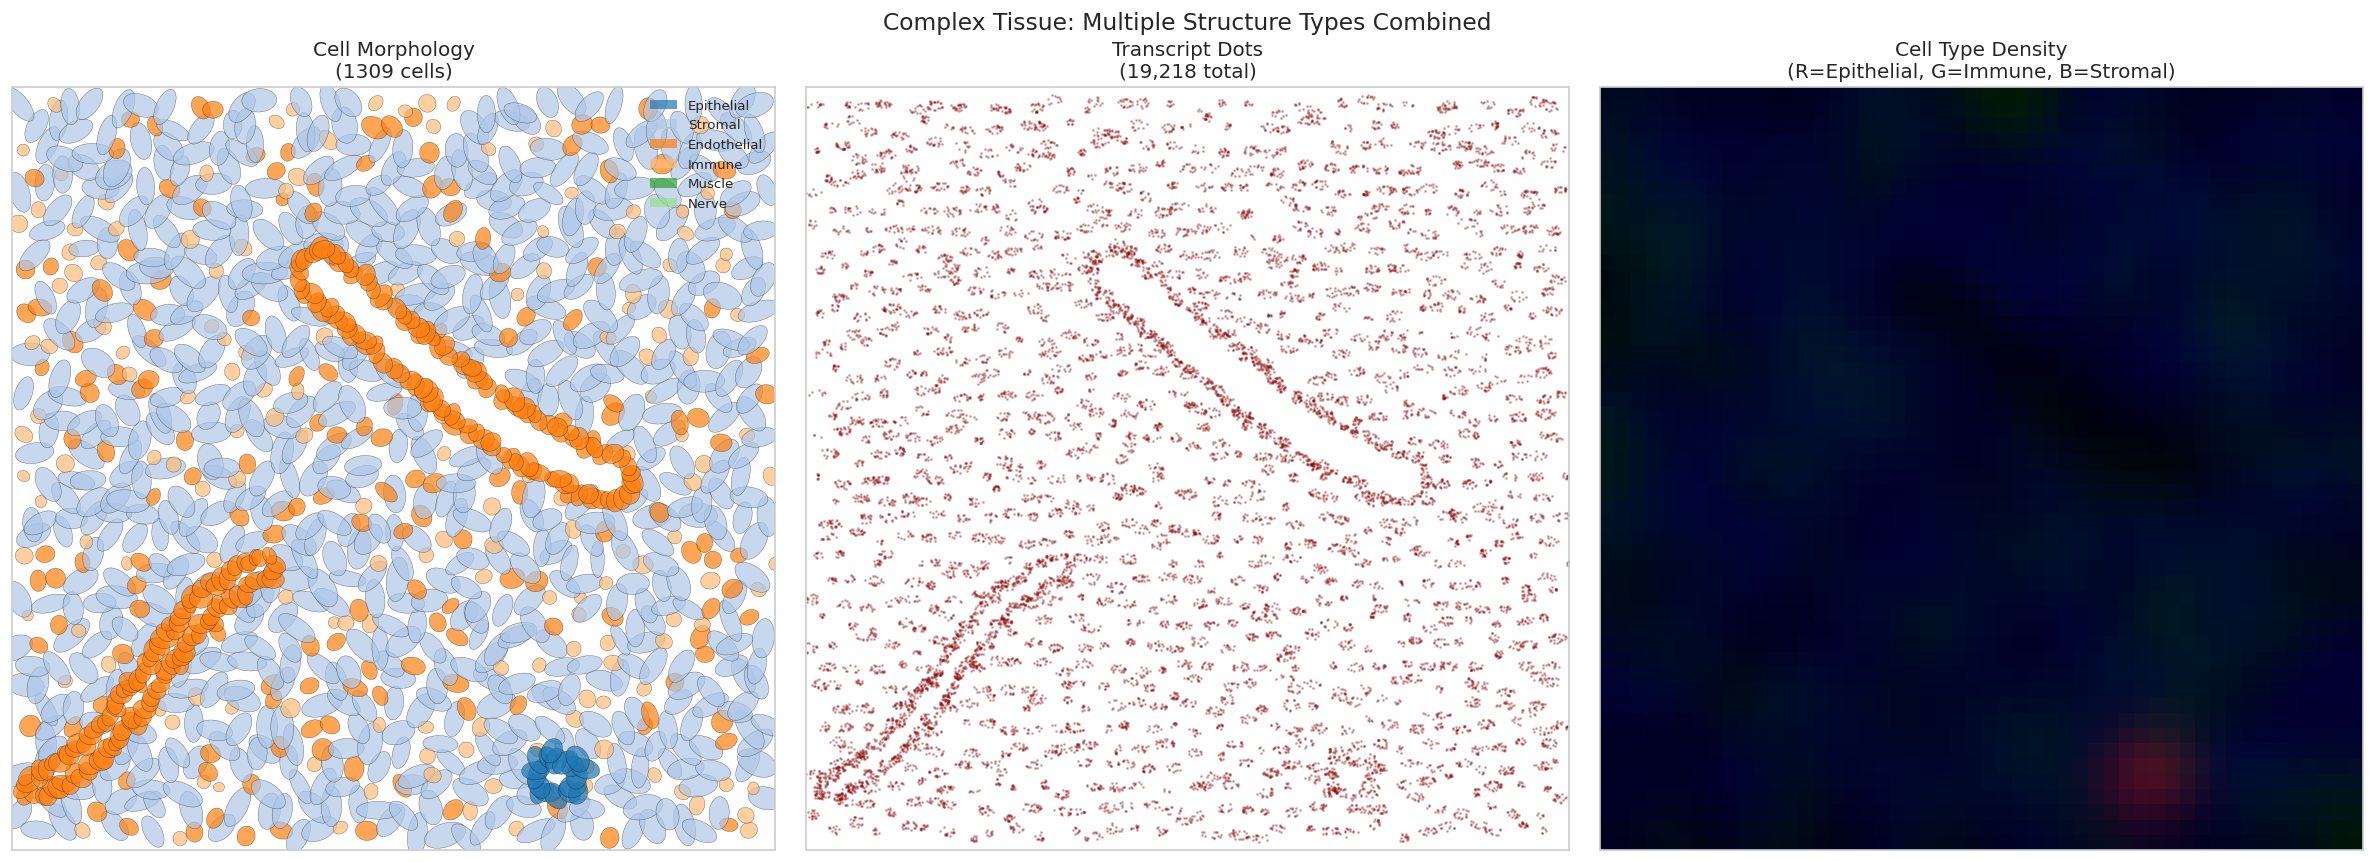

In [13]:
# Beautiful visualization of complex tissue
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Cell types
ax = axes[0]
ellipses = []
cell_colors = []
for i in range(len(fov.cell_centroids)):
    ellipse = Ellipse(
        xy=(fov.cell_centroids[i, 0], fov.cell_centroids[i, 1]),
        width=2 * fov.cell_major_axis[i],
        height=2 * fov.cell_minor_axis[i],
        angle=np.degrees(fov.cell_rotation[i]),
    )
    ellipses.append(ellipse)
    cell_colors.append(fov.cell_colors[i])

collection = PatchCollection(ellipses, alpha=0.7)
collection.set_facecolors(cell_colors)
collection.set_edgecolors('black')
collection.set_linewidths(0.2)
ax.add_collection(collection)
ax.set_xlim(0, frame_size_large)
ax.set_ylim(0, frame_size_large)
ax.set_aspect('equal')
ax.set_title(f'Cell Morphology\n({fov.n_cells} cells)', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cell_props.colordict[i], alpha=0.7, 
                         label=tissue._cell_type_names[i]) 
                   for i in range(n_cell_types)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# Transcript dots
ax = axes[1]
ax.scatter(dots_df['x'], dots_df['y'], s=0.5, alpha=0.3, c='darkred')
ax.set_xlim(0, frame_size_large)
ax.set_ylim(0, frame_size_large)
ax.set_aspect('equal')
ax.set_title(f'Transcript Dots\n({len(dots_df):,} total)', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])

# Cell type density heatmap
ax = axes[2]
from scipy.ndimage import gaussian_filter

# Create density maps for each cell type
bins = 50
density_maps = []
for ct in range(n_cell_types):
    mask = fov.class_instance == ct
    if mask.sum() > 0:
        H, xedges, yedges = np.histogram2d(
            fov.cell_centroids[mask, 0],
            fov.cell_centroids[mask, 1],
            bins=bins,
            range=[[0, frame_size_large], [0, frame_size_large]]
        )
        density_maps.append(gaussian_filter(H.T, sigma=2))
    else:
        density_maps.append(np.zeros((bins, bins)))

# Show epithelial (0) in red, stromal (1) in blue, immune (3) in green
rgb = np.zeros((bins, bins, 3))
if len(density_maps) > 0:
    max_val = max(d.max() for d in density_maps) + 1
    rgb[:, :, 0] = density_maps[0] / max_val  # Epithelial - Red
    rgb[:, :, 2] = density_maps[1] / max_val  # Stromal - Blue
    rgb[:, :, 1] = density_maps[3] / max_val if len(density_maps) > 3 else 0  # Immune - Green

ax.imshow(rgb, extent=[0, frame_size_large, 0, frame_size_large], origin='lower', aspect='equal')
ax.set_title('Cell Type Density\n(R=Epithelial, G=Immune, B=Stromal)', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])

plt.suptitle('Complex Tissue: Multiple Structure Types Combined', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary

| Structure | Use Case | Key Parameters |
|-----------|----------|----------------|
| **VacuolatedStructure** | Glands, acini, crypts | `hole_scale_factor`, `scale`, `smoothing_iterations` |
| **LinearLumenStructure** | Vessels, ducts | `length`, `outer_radius`, `wall_thickness`, `curvature` |
| **LayeredElement** | Epidermis, cortex | `layer_boundaries`, `layer_rules`, `orientation` |
| **BranchingStructure** | Vasculature, nerves | `max_depth`, `branching_angle`, `branch_length`, `radius_decay` |
| **FibrillarStructure** | Collagen, muscle | `n_fibers`, `fiber_width`, `orientation`, `waviness` |
| **ClusterElement** | Follicles, tumors | `radius`, `density_profile`, `fixed_center` |
| **GlandularUnit** | Complete glands | `n_acini`, `acinus_radius`, `duct_radius`, `arrangement` |
| **InterfaceElement** | Tissue boundaries | `interface_width`, `orientation`, `waviness`, `rules_side_a/b` |
| **StromalElement** | Background tissue | `cell_density`, `heterogeneity` |

### Key Takeaways

1. **Combine elements** using `FOVDistribution` for realistic tissues
2. **Rules control** cell type patterns within each structure
3. **Layer and distance-based rules** create biological gradients
4. **Cell properties** add realistic morphology

### Next Steps

- Experiment with different rule combinations
- Try composite rules for complex cell type patterns
- Combine multiple structures in a single FOV for realistic tissue architecture